In [1]:
# ==============================
# 9. FEATURE RELATIONSHIP ANALYSIS
# ==============================

import pandas as pd

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges safely
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ==============================
# 1. Churn vs Key Numerical Features
# ==============================
print("\n--- Churn vs Monthly Charges (Mean) ---")
print(df.groupby('Churn')['MonthlyCharges'].mean())

print("\n--- Churn vs Total Charges (Mean) ---")
print(df.groupby('Churn')['TotalCharges'].mean())

print("\n--- Churn vs Tenure (Mean) ---")
print(df.groupby('Churn')['tenure'].mean())

# ==============================
# 2. Contract vs Tenure & Charges
# ==============================
print("\n--- Contract vs Tenure (Mean) ---")
print(df.groupby('Contract')['tenure'].mean())

print("\n--- Contract vs Monthly Charges (Mean) ---")
print(df.groupby('Contract')['MonthlyCharges'].mean())

# ==============================
# 3. Internet Service vs Charges & Churn
# ==============================
print("\n--- Internet Service vs Monthly Charges (Mean) ---")
print(df.groupby('InternetService')['MonthlyCharges'].mean())

print("\n--- Internet Service vs Churn Rate ---")
print(df.groupby('InternetService')['Churn'].value_counts(normalize=True) * 100)

# ==============================
# 4. Payment Method vs Churn
# ==============================
print("\n--- Payment Method vs Churn Rate ---")
print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True) * 100)

# ==============================
# 5. Correlation (Numerical Features)
# ==============================
print("\n--- Correlation Matrix (Numerical Features) ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr())

# ==============================
# 6. Contract vs Churn Relationship
# ==============================
print("\n--- Contract vs Churn Rate ---")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100)

# ==============================
# 7. Gender vs Churn
# ==============================
print("\n--- Gender vs Churn Rate ---")
print(df.groupby('gender')['Churn'].value_counts(normalize=True) * 100)


--- Churn vs Monthly Charges (Mean) ---
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

--- Churn vs Total Charges (Mean) ---
Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64

--- Churn vs Tenure (Mean) ---
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

--- Contract vs Tenure (Mean) ---
Contract
Month-to-month    18.036645
One year          42.044807
Two year          56.735103
Name: tenure, dtype: float64

--- Contract vs Monthly Charges (Mean) ---
Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

--- Internet Service vs Monthly Charges (Mean) ---
InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

--- Internet Service vs Churn Rate ---
InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      

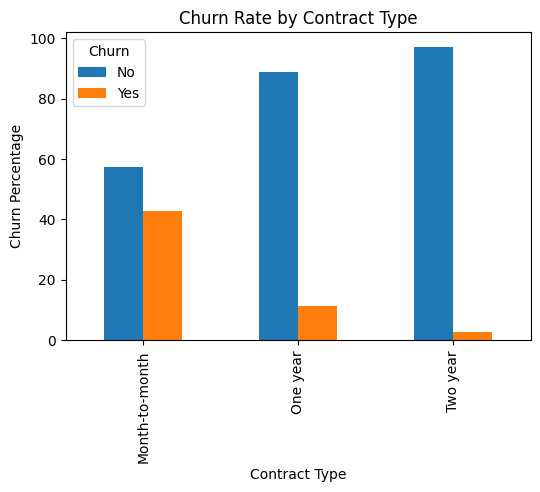

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', figsize=(6,4))

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Percentage')
plt.show()

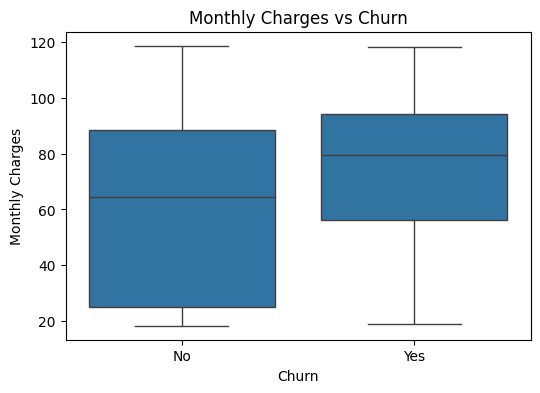

In [3]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()